Using device: cuda

  λ = 1e-05  |  epochs=30  |  device=cuda
  Ep |   TotalL |     ClsL |        SpL |  TrainAcc |  TestAcc |  Sparse%
----------------------------------------------------------------------
   1 |  20.7418 |   1.8948 |  1884695.8 |    38.66% |   40.62% |    0.00%  (34.1s)
   5 |  20.3542 |   1.5725 |  1878170.0 |    46.82% |   48.90% |    0.00%  (35.6s)
  10 |  20.2648 |   1.4838 |  1878099.2 |    49.35% |   51.44% |    0.00%  (34.6s)
  15 |  20.2032 |   1.4222 |  1878099.8 |    52.17% |   54.15% |    0.00%  (36.1s)
  20 |  20.1375 |   1.3564 |  1878111.2 |    54.94% |   55.89% |    0.00%  (34.6s)
  25 |  20.0908 |   1.3096 |  1878123.9 |    56.91% |   57.66% |    0.00%  (35.8s)
  30 |  20.0719 |   1.2906 |  1878130.9 |    57.55% |   57.98% |    0.00%  (35.4s)

  ✔  Final Test Accuracy : 57.98%
  ✔  Final Sparsity      : 0.00%

  λ = 1e-04  |  epochs=30  |  device=cuda
  Ep |   TotalL |     ClsL |        SpL |  TrainAcc |  TestAcc |  Sparse%
---------------------------

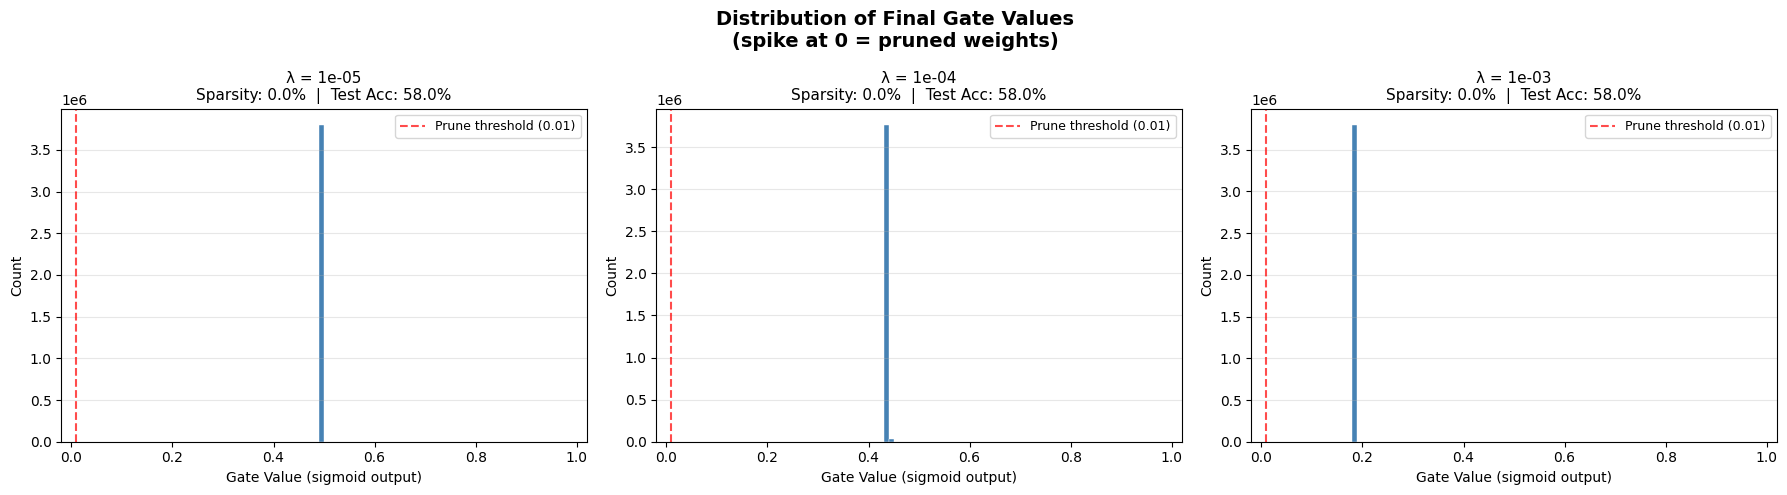

Saved: gate_distributions.png


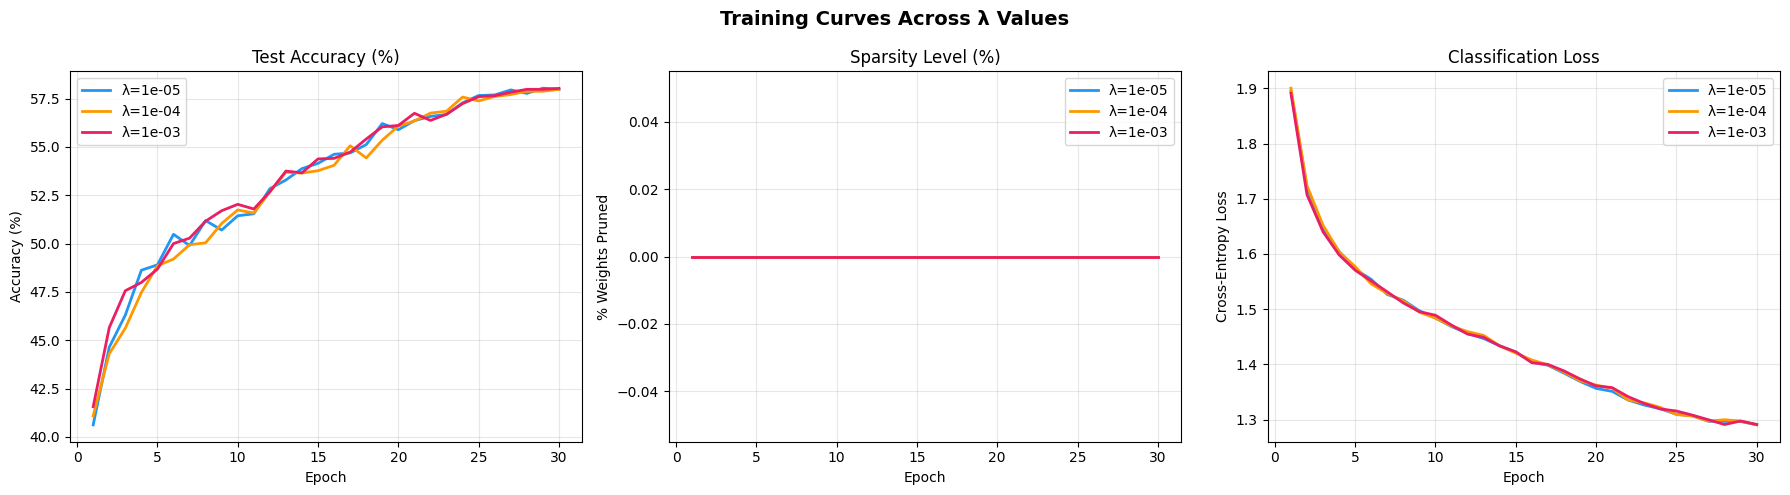

Saved: training_curves.png

Per-layer sparsity breakdown for each λ:
Layer     λ=1e-05 sparse%  λ=1e-04 sparse%  λ=1e-03 sparse%
-----------------------------------------------------------------
L1 (3072→1024)                   0.00%               0.00%               0.00%
L2 (1024→512)                    0.00%               0.00%               0.00%
L3 (512→256)                     0.00%               0.00%               0.00%
L4 (256→10)                      0.00%               0.00%               0.00%


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

class PrunableLinear(nn.Module):
    """
    A custom linear layer augmented with learnable gate parameters.

    Each weight w_ij has a corresponding gate_score g_ij.
    Gates are computed as: gate = sigmoid(gate_score)  ∈ (0, 1)
    Effective weight:       pruned_weight = weight * gate

    When gate → 0, the connection is effectively pruned.
    The L1 sparsity loss drives most gates toward zero.

    Gradients flow through both `weight` and `gate_scores` via autograd
    since all operations (sigmoid, element-wise multiply, F.linear) are
    differentiable PyTorch ops.
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, nonlinearity='relu')

    def forward(self,x:torch.Tensor)->torch.Tensor:
        gates=torch.sigmoid(self.gate_scores)
        pruned_weights=self.weight*gates
        return F.linear(x,pruned_weights,self.bias)

    def gate_values(self) -> torch.Tensor:
        """Returns the current gate values (detached) for analysis."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below `threshold` (i.e. effectively pruned)."""
        gates = self.gate_values()
        return (gates < threshold).float().mean().item()

class SelfPruningNet(nn.Module):
    """
    Feed-forward network for CIFAR-10 classification.
    All linear layers are replaced with PrunableLinear layers.

    Architecture:
        Flatten → 3072
        PrunableLinear(3072, 1024) → BN → ReLU → Dropout
        PrunableLinear(1024,  512) → BN → ReLU → Dropout
        PrunableLinear( 512,  256) → BN → ReLU → Dropout
        PrunableLinear( 256,   10)  [logits]
    """

    def __init__(self, dropout_p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            PrunableLinear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            PrunableLinear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            PrunableLinear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def prunable_layers(self):
        """Yields all PrunableLinear sub-modules."""
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                yield module

    def sparsity_loss(self) -> torch.Tensor:
        """
        L1 norm of all gate values across every PrunableLinear layer.
        SparsityLoss = Σ_layers Σ_{i,j} sigmoid(gate_score_{i,j})

        L1 on the sigmoid output encourages gates to collapse to 0:
          - The sigmoid is bounded in (0,1), so L1 = sum of gate values.
          - Gradient of L1 w.r.t. gate = sign(gate) = 1 (always positive here).
          - This constant gradient keeps pulling gate_scores → -∞,
            hence sigmoid → 0, pruning the connection.
        """
        total = torch.tensor(0.0, device=DEVICE)
        for layer in self.prunable_layers():
            total = total + torch.sigmoid(layer.gate_scores).sum()
        return total

    def overall_sparsity(self, threshold: float = 1e-2) -> float:
        """Percentage of all weights effectively pruned across the network."""
        pruned = 0
        total  = 0
        for layer in self.prunable_layers():
            gates  = layer.gate_values()
            pruned += (gates < threshold).sum().item()
            total  += gates.numel()
        return 100.0 * pruned / total if total > 0 else 0.0

    def all_gate_values(self) -> torch.Tensor:
        """Concatenated flat tensor of all gate values (for plotting)."""
        return torch.cat([l.gate_values().flatten() for l in self.prunable_layers()])


def get_cifar10_loaders(batch_size: int = 256):
    """
    Returns (train_loader, test_loader) for CIFAR-10.
    Applies standard augmentation for training and normalization for both.
    """
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_set = torchvision.datasets.CIFAR10(
        root='./data', train=True,  download=True, transform=train_transform)
    test_set  = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

def train_one_epoch(model, loader, optimizer, lambda_sparse: float):
    """
    Trains for one epoch.
    Returns (avg_total_loss, avg_cls_loss, avg_sparsity_loss).
    """
    model.train()
    total_loss_sum = cls_loss_sum = sp_loss_sum = 0.0
    n_batches = len(loader)

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        logits       = model(images)
        cls_loss     = F.cross_entropy(logits, labels)
        sp_loss      = model.sparsity_loss()
        total_loss   = cls_loss + lambda_sparse * sp_loss

        total_loss.backward()
        optimizer.step()

        total_loss_sum += total_loss.item()
        cls_loss_sum   += cls_loss.item()
        sp_loss_sum    += sp_loss.item()

    return (total_loss_sum / n_batches,
            cls_loss_sum   / n_batches,
            sp_loss_sum    / n_batches)


@torch.no_grad()
def evaluate(model, loader):
    """Returns (accuracy %, avg_cross_entropy_loss)."""
    model.eval()
    correct = total = 0
    loss_sum = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss_sum += F.cross_entropy(logits, labels).item()
        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return 100.0 * correct / total, loss_sum / len(loader)

def run_experiment(lambda_sparse: float,
                   epochs: int = 30,
                   lr: float = 1e-3,
                   batch_size: int = 256,
                   verbose: bool = True):
    """
    Trains a SelfPruningNet for `epochs` with the given sparsity coefficient.
    Returns a results dict with losses, accuracies, sparsity, and gate values.
    """
    train_loader, test_loader = get_cifar10_loaders(batch_size)

    model     = SelfPruningNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'total_loss': [], 'cls_loss': [], 'sp_loss': [],
        'train_acc': [], 'test_acc': [], 'sparsity': []
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"  λ = {lambda_sparse:.0e}  |  epochs={epochs}  |  device={DEVICE}")
        print(f"{'='*60}")
        print(f"{'Ep':>4} | {'TotalL':>8} | {'ClsL':>8} | {'SpL':>10} | "
              f"{'TrainAcc':>9} | {'TestAcc':>8} | {'Sparse%':>8}")
        print("-"*70)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        total_l, cls_l, sp_l = train_one_epoch(
            model, train_loader, optimizer, lambda_sparse)
        tr_acc, _ = evaluate(model, train_loader)
        te_acc, _ = evaluate(model, test_loader)
        sparsity  = model.overall_sparsity()
        scheduler.step()

        history['total_loss'].append(total_l)
        history['cls_loss'].append(cls_l)
        history['sp_loss'].append(sp_l)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['sparsity'].append(sparsity)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            dt = time.time() - t0
            print(f"{epoch:>4} | {total_l:>8.4f} | {cls_l:>8.4f} | "
                  f"{sp_l:>10.1f} | {tr_acc:>8.2f}% | "
                  f"{te_acc:>7.2f}% | {sparsity:>7.2f}%  ({dt:.1f}s)")

    final_test_acc, _ = evaluate(model, test_loader)
    final_sparsity    = model.overall_sparsity()
    gate_values       = model.all_gate_values().cpu().numpy()

    if verbose:
        print(f"\n  ✔  Final Test Accuracy : {final_test_acc:.2f}%")
        print(f"  ✔  Final Sparsity      : {final_sparsity:.2f}%")

    return {
        'lambda':       lambda_sparse,
        'model':        model,
        'history':      history,
        'test_acc':     final_test_acc,
        'sparsity':     final_sparsity,
        'gate_values':  gate_values,
    }

LAMBDAS = [1e-5, 1e-4, 1e-3]
EPOCHS  = 30

results = {}
for lam in LAMBDAS:
    results[lam] = run_experiment(lambda_sparse=lam, epochs=EPOCHS)

print("\n" + "="*52)
print(f"  {'Lambda':<12} | {'Test Accuracy':>14} | {'Sparsity Level':>14}")
print("="*52)
for lam, r in results.items():
    print(f"  {lam:<12.0e} | {r['test_acc']:>13.2f}% | {r['sparsity']:>13.2f}%")
print("="*52)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Final Gate Values\n(spike at 0 = pruned weights)",
             fontsize=14, fontweight='bold')

for ax, lam in zip(axes, LAMBDAS):
    gates = results[lam]['gate_values']
    pruned_pct = (gates < 1e-2).mean() * 100

    ax.hist(gates, bins=100, color='steelblue', edgecolor='white',
            linewidth=0.3, range=(0, 1))
    ax.set_title(f"λ = {lam:.0e}\nSparsity: {pruned_pct:.1f}%  |  "
                 f"Test Acc: {results[lam]['test_acc']:.1f}%", fontsize=11)
    ax.set_xlabel("Gate Value (sigmoid output)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.axvline(x=0.01, color='red', linestyle='--', alpha=0.7,
               label='Prune threshold (0.01)')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("gate_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gate_distributions.png")



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curves Across λ Values", fontsize=14, fontweight='bold')
colors = ['#2196F3', '#FF9800', '#E91E63']
epochs_range = range(1, EPOCHS + 1)

for i, (lam, color) in enumerate(zip(LAMBDAS, colors)):
    h = results[lam]['history']
    label = f"λ={lam:.0e}"
    axes[0].plot(epochs_range, h['test_acc'], color=color, label=label, linewidth=2)

    axes[1].plot(epochs_range, h['sparsity'], color=color, label=label, linewidth=2)

    axes[2].plot(epochs_range, h['cls_loss'], color=color, label=label, linewidth=2)

axes[0].set_title("Test Accuracy (%)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")

axes[1].set_title("Sparsity Level (%)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("% Weights Pruned")

axes[2].set_title("Classification Loss")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Cross-Entropy Loss")

for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

print("\nPer-layer sparsity breakdown for each λ:")
print(f"{'Layer':<8}", end="")
for lam in LAMBDAS:
    print(f"  λ={lam:.0e} sparse%", end="")
print()
print("-" * 65)

layer_names = ["L1 (3072→1024)", "L2 (1024→512)", "L3 (512→256)", "L4 (256→10)"]

for lam in LAMBDAS:
    model = results[lam]['model']
    layers = list(model.prunable_layers())
    results[lam]['layer_sparsities'] = [l.sparsity() * 100 for l in layers]

for i, name in enumerate(layer_names):
    print(f"{name:<18}", end="")
    for lam in LAMBDAS:
        sp = results[lam]['layer_sparsities'][i]
        print(f"  {sp:>17.2f}%", end="")
    print()